## Strategy Evaluation

- Convert model probabilities into trading signals  
- Trade next-step returns  
- Include transaction costs  
- Evaluate PnL, Sharpe, drawdown  etc

## Goal

Check whether predictive signal translates into real trading performance, not just AUC.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

from microstructure_alpha.data.loader import load_parquet_glob
from microstructure_alpha.models.train import run_model_parallel, run_fold
from microstructure_alpha.plots import plot_fold_aucs, plot_rolling_calibration
from microstructure_alpha.features.feature_lists import (
    MID_PRICE_MOVE_FINAL,
    SIGN_MODEL_FEATURES,
)
from microstructure_alpha.models.model_configs import (
    calibrate_model,
    LINEAR_MODELS,
    TREE_MODELS,
    OTHER_MODELS,
)

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

### Data Setup

Load dataset and define targets for move and sign models.

In [3]:
target_sign = "mid_price_change_1_sign"
target_move = "mid_price_moves"
final_dataset = load_parquet_glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet",
    sort_by="timestamp",
)
final_dataset["mid_price_change_1_sign"] = final_dataset[
    "mid_price_change_1_sign"
].replace(-1.0, 0.0)

### Model Setup

Define models and cross-validation scheme.

In [4]:
move_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=50,
    max_features=0.2,
    n_jobs=1,
    random_state=42,
)

sign_model = XGBClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.02,
    subsample=0.7,
    colsample_bytree=0.5,
    reg_lambda=5.0,
    reg_alpha=1.0,
    min_child_weight=40,
    gamma=1.0,
    n_jobs=1,
    random_state=42,
    eval_metric="logloss",
)

In [5]:
splits = 10
size_data = len(final_dataset)
tscv = TimeSeriesSplit(n_splits=splits, gap=50, max_train_size=int(size_data / splits))

In [6]:
X = final_dataset
X_move = X[MID_PRICE_MOVE_FINAL]
y_move = final_dataset[target_move]


X_sign = X[SIGN_MODEL_FEATURES]
y_sign = final_dataset[target_sign]
mask_sign = final_dataset["mid_price_moves"] == 1

In [7]:
move_result = {}
sign_result = {}

move_result["rf"] = run_model_parallel(X_move, y_move, move_model, tscv, n_jobs=4)
sign_result["xgb_stable"] = run_model_parallel(
    X_sign, y_sign, sign_model, tscv, n_jobs=4, mask=mask_sign
)

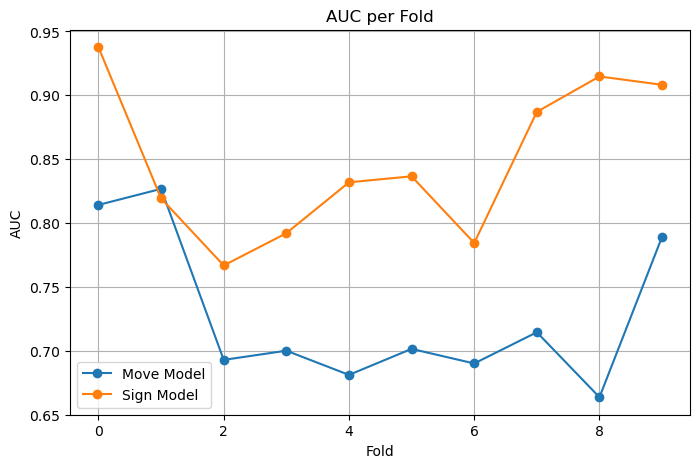

In [8]:
move_aucs = move_result["rf"]["fold_aucs"]
sign_aucs = sign_result["xgb_stable"]["fold_aucs"]

x = np.arange(len(move_aucs))

plt.figure(figsize=(8, 5))

plt.plot(x, move_aucs, marker="o", label="Move Model")
plt.plot(x, sign_aucs, marker="o", label="Sign Model")

plt.xlabel("Fold")
plt.ylabel("AUC")
plt.title("AUC per Fold")

plt.legend()
plt.grid(True)
plt.show()

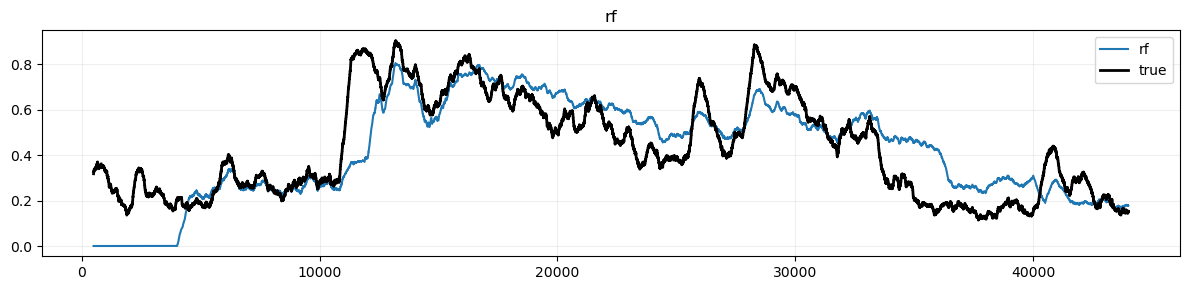

C:\Users\jayod\AppData\Local\Temp\ipykernel_20712\664905310.py:6: RuntimeWarning: Mean of empty slice
  preds = np.nanmean(sign_result["xgb_stable"]["fold_oof"], axis=0)


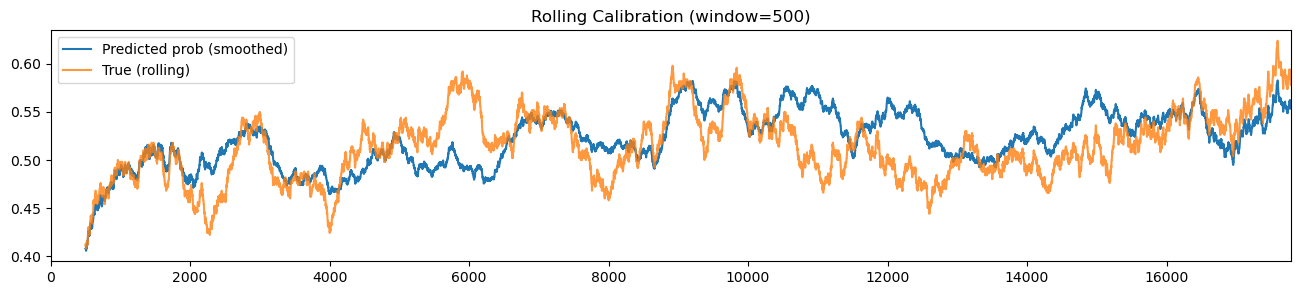

In [9]:
from microstructure_alpha.plots import plot_model_calibration

# move model
plot_model_calibration(move_result, y_move)

preds = np.nanmean(sign_result["xgb_stable"]["fold_oof"], axis=0)

valid = ~np.isnan(preds)

plot_rolling_calibration(preds[valid], y_sign.values[valid], window=500)

Predicted probabilities track realised outcomes but are noisy.

### Signal Construction

Combine move and sign predictions:

- Trade only when move probability is high  
- Use sign model for direction  
- Apply thresholds to focus on high-confidence trades

In [10]:
move_preds = pd.Series(
    np.nansum(move_result["rf"]["fold_oof"], axis=0), index=final_dataset.index
)
sign_preds = pd.Series(
    np.nansum(sign_result["xgb_stable"]["fold_oof_full"], axis=0),
    index=final_dataset.index,
)
returns = final_dataset["mid_price_change_1"]
spread = final_dataset["spread"]
valid = sign_preds.notna() & move_preds.notna()

sign_preds = sign_preds[valid]
move_preds = move_preds[valid]
returns = returns[valid]
spread = spread[valid]

In [11]:
from microstructure_alpha.backtest.engine import evaluate_strategy


all_metrics, pnl, signal = evaluate_strategy(
    sign_preds=sign_preds,
    move_preds=move_preds,
    returns=returns,
    spread=spread,
    move_quantile=0.7,
    sign_threshold=0.5,
)

In [12]:
from statsmodels.tsa.stattools import acf

acf_vals = acf(pnl, nlags=100)
rho_sum = np.sum(acf_vals[1:])

rho_sum

np.float64(0.2232917183195457)

In [13]:
from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["Metric", "Value"]

for k, v in all_metrics.items():

    if k == "quantile_means":
        continue

    table.add_row([k, round(v, 4)])

print(table)

+--------------------------------+-----------+
|             Metric             |   Value   |
+--------------------------------+-----------+
|             sharpe             |   0.049   |
|        sharpe_per_trade        |    0.09   |
|           total_pnl            | 4479.9335 |
|          mean_return           |   0.1018  |
|           volatility           |   2.0777  |
|          max_drawdown          | -199.5535 |
|          hit_rate_all          |   0.1103  |
|        hit_rate_trades         |   0.3676  |
|           trade_freq           |    0.3    |
|         avg_trade_pnl          |   0.3403  |
|          trade_sharpe          |    0.09   |
|          avg_position          |   0.1131  |
|          max_position          |   0.7345  |
|       avg_pnl_when_move        |   0.2392  |
| directional_accuracy_when_move |   0.5791  |
|         move_coverage          |   0.4477  |
|         wasted_trades          |   0.1089  |
|          missed_moves          |   0.2358  |
|            

Signal shows positive IC, indicating real predictive power

Sharpe is low due to high noise at the 1-second horizon, despite positive PnL

Hit rate is below 50%, which is expected

The strategy relies on larger winning trades outweighing more frequent small losses

In [14]:
trade_mask = signal != 0

wins = pnl[(pnl > 0) & trade_mask]
losses = pnl[(pnl < 0) & trade_mask]

win_rate = len(wins) / (len(wins) + len(losses))
avg_win = wins.mean()
avg_loss = losses.mean()

print("win_rate:", win_rate)
print("avg_win:", avg_win)
print("avg_loss:", avg_loss)
print("expected:", win_rate * avg_win + (1 - win_rate) * avg_loss)

win_rate: 0.36757575757575756
avg_win: 3.235773533975726
avg_loss: -1.3426765574908184
expected: 0.34025070340279306


## Metrics Explanation

- sharpe  
Risk-adjusted return. Mean PnL divided by volatility. Measures efficiency of the strategy.

- total_pnl  
Total profit over the backtest period.

- mean_return  
Average PnL per timestep.

- volatility  
Standard deviation of PnL. Measures variability of returns.

- max_drawdown  
Largest peak-to-trough loss. Indicates worst risk scenario.

- hit_rate  
Fraction of trades with positive PnL.

- trade_freq  
Fraction of timesteps where a trade is taken.

- avg_trade_pnl  
Average PnL per executed trade.

- trade_sharpe  
Sharpe computed only on trade PnL, not all timesteps.

- avg_position  
Average absolute position size. Shows how aggressively the model trades.

- max_position  
Maximum position taken. Indicates peak exposure.

- avg_pnl_when_move  
Average PnL conditional on actual price movement. Measures performance in active periods.

- directional_accuracy_when_move  
Accuracy of direction prediction when a move occurs.

- move_coverage  
Fraction of true moves where the model trades. Measures how much opportunity is captured.

- wasted_trades  
Fraction of trades taken when no move happens. Pure noise trades.

- missed_moves  
Fraction of actual moves where the model did not trade.

- ic  
Correlation between signal and future returns. Measures overall signal quality.

- ic_non_zero  
IC computed only on non-zero signals. Measures quality when the model actually acts.

In [15]:
import numpy as np
import pandas as pd

move_quantiles = np.linspace(0.0001, 0.01, 40)
sign_thresholds = np.linspace(0.04, 0.90, 40)

results = []

for mq in move_quantiles:
    for st in sign_thresholds:

        all_metrics, pnl, signal = evaluate_strategy(
            sign_preds=sign_preds,
            move_preds=move_preds,
            returns=returns,
            spread=spread,
            move_quantile=mq,
            sign_threshold=st,
        )

        trade_freq = all_metrics["trade_freq"]
        trade_sharpe_per_trade = all_metrics["sharpe_per_trade"]
        trade_total_pnl = all_metrics["total_pnl"]
        trade_max_drawdown = all_metrics["max_drawdown"]

        if trade_freq < 0.05:
            continue

        score = trade_sharpe_per_trade
        results.append({"move_q": mq, "sign_th": st, "score": score, **all_metrics})

df = pd.DataFrame(results)

best = df.sort_values("score", ascending=False).iloc[0]

print(best)

move_q                               0.003908
sign_th                              0.855897
score                                0.135585
sharpe                               0.048492
sharpe_per_trade                     0.135585
total_pnl                         2566.292812
mean_return                          0.058327
volatility                           1.202833
max_drawdown                      -107.132539
hit_rate_all                         0.036206
hit_rate_trades                      0.276131
trade_freq                           0.131120
avg_trade_pnl                        0.446826
trade_sharpe                         0.135585
avg_position                         0.054445
max_position                         0.734534
avg_pnl_when_move                    0.137093
directional_accuracy_when_move       0.692408
move_coverage                        0.122698
wasted_trades                        0.078731
missed_moves                         0.374585
ic                                